In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from PIL import Image
import os
import numpy as np

# --- 1. Custom Dataset für automatische Klassifizierung ---
class MotorDataset(Dataset):
    def __init__(self, main_dir, img_list, transform=None):
        self.main_dir = main_dir
        self.transform = transform
        self.all_imgs = img_list
        
        # Angepasst an deine Dateinamen
        self.class_names = ['S1000R_2015', 'S1000R_2017', 'S1000RR_2014']
        self.label_map = {name: i for i, name in enumerate(self.class_names)}

    def __len__(self):
        return len(self.all_imgs)

    def __getitem__(self, idx):
        img_loc = os.path.join(self.main_dir, self.all_imgs[idx])
        image = Image.open(img_loc).convert("RGB")
        
        filename = self.all_imgs[idx]
        label = -1
        for name in self.class_names:
            if name in filename:
                label = self.label_map[name]
                break
        
        if label == -1:
            raise ValueError(f"Datei {filename} konnte keiner Klasse zugeordnet werden!")

        if self.transform:
            image = self.transform(image)
            
        return image, label

# --- 2. Konfiguration & Chronologischer Split (Anti-Leakage) ---
dataset_path = '../data/processed/dataset_idle'

data_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

all_filenames = [f for f in os.listdir(dataset_path) if f.endswith('.png')]

train_list = []
val_list = []

files_by_source = {}
for fname in all_filenames:
    source = fname.split('_idle_')[0]
    if source not in files_by_source:
        files_by_source[source] = []
    files_by_source[source].append(fname)

for source, images in files_by_source.items():
    images.sort(key=lambda x: float(x.split('_')[-1].replace('s.png', '')))
    split_idx = int(len(images) * 0.8)
    train_list.extend(images[0:split_idx])
    val_list.extend(images[split_idx:])

train_dataset = MotorDataset(dataset_path, train_list, transform=data_transforms)
val_dataset = MotorDataset(dataset_path, val_list, transform=data_transforms)

num_classes = len(train_dataset.class_names)
train_size = len(train_dataset)
val_size = len(val_dataset)

# --- Balancing ---
# Labels für alle Trainingsbilder sammeln
train_labels = []
for i in range(len(train_dataset)):
    _, label = train_dataset[i]
    train_labels.append(label)

# Umwandlung in NumPy Array für fehlerfreie Logik
train_labels = np.array(train_labels)

# Klassen-Häufigkeit zählen
class_sample_count = np.array([len(np.where(train_labels == t)[0]) for t in range(num_classes)])

# Gewicht pro Klasse
weight = 1. / class_sample_count
samples_weight = np.array([weight[t] for t in train_labels])

samples_weight = torch.from_numpy(samples_weight).double()
sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

# DataLoader: train_loader nutzt jetzt den Sampler (shuffle muss False sein bei Sampler!)
train_loader = DataLoader(train_dataset, batch_size=8, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# --- 3. Modell-Definition (Transfer Learning) ---
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# --- 4. Training-Parameter ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- 5. Training-Schleife ---
print(f"Ehrlicher Split: {train_size} Training / {val_size} Validierung")
print(f"Klassen-Verteilung im Training: {class_sample_count}")
print(f"Starte Training für {num_classes} Klassen...")

for epoch in range(10):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
    
    val_acc = 100 * correct / val_size if val_size > 0 else 0
    print(f"Epoche {epoch+1:02d} | Loss: {running_loss/len(train_loader):.4f} | Val-Acc: {val_acc:.2f}%")

print("Training abgeschlossen.")

/opt/anaconda3/envs/s1000-diagnoser/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/s1000-diagnoser/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Ehrlicher Split: 182 Training / 47 Validierung
Klassen-Verteilung im Training: [70 32 80]
Starte Training für 3 Klassen...
Epoche 01 | Loss: 0.2019 | Val-Acc: 100.00%
Epoche 02 | Loss: 0.1298 | Val-Acc: 100.00%
Epoche 03 | Loss: 0.0373 | Val-Acc: 97.87%
Epoche 04 | Loss: 0.0190 | Val-Acc: 100.00%
Epoche 05 | Loss: 0.0106 | Val-Acc: 100.00%
Epoche 06 | Loss: 0.0338 | Val-Acc: 100.00%
Epoche 07 | Loss: 0.0147 | Val-Acc: 70.21%
Epoche 08 | Loss: 0.0810 | Val-Acc: 100.00%
Epoche 09 | Loss: 0.0738 | Val-Acc: 57.45%
Epoche 10 | Loss: 0.1554 | Val-Acc: 97.87%
Training abgeschlossen.


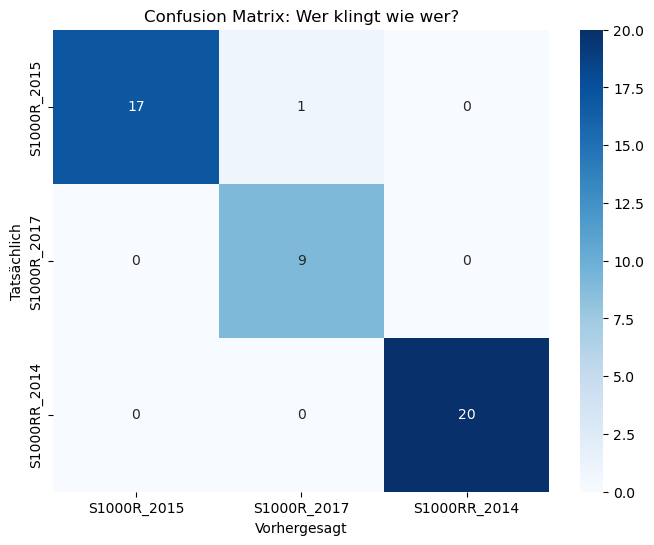

In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Matrix berechnen
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=val_dataset.class_names, yticklabels=val_dataset.class_names, cmap='Blues')
plt.xlabel('Vorhergesagt')
plt.ylabel('Tatsächlich')
plt.title('Confusion Matrix: Wer klingt wie wer?')
plt.show()

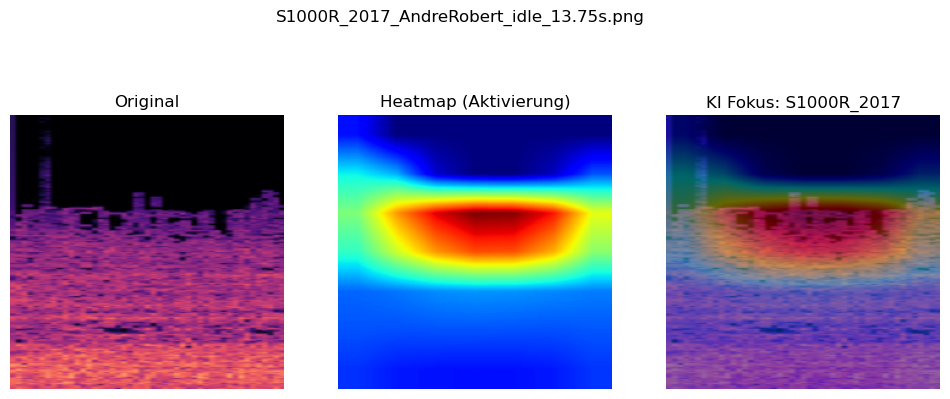

In [36]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import cv2

# --- 1. Vorbereitung & Hooks ---
# Wir müssen die Aktivierungen und Gradienten der letzten Faltungsschicht speichern
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hooks registrieren
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor, class_idx):
        # Forward Pass
        output = self.model(input_tensor)
        self.model.zero_grad()
        
        # Backward Pass für die Zielklasse
        loss = output[0, class_idx]
        loss.backward()
        
        # Gradienten mitteln (Global Average Pooling)
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        
        # Gewichtete Summe der Aktivierungen
        cam = torch.sum(weights * self.activations, dim=1).squeeze()
        
        # ReLU und Normalisierung
        cam = np.maximum(cam.detach().cpu().numpy(), 0)
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# --- 2. Grad-CAM Ausführung ---
def visualize_gradcam(img_path, model, transform, class_names):
    model.eval()
    
    # Bild laden und transformieren
    img_pil = Image.open(img_path).convert('RGB')
    input_tensor = transform(img_pil).unsqueeze(0).to(device)
    
    # Grad-CAM für die letzte Schicht von ResNet18 (layer4) initialisieren
    # Bei ResNet18 ist das oft model.layer4[1].conv2
    target_layer = model.layer4[-1] 
    grad_cam = GradCAM(model, target_layer)
    
    # Vorhersage treffen
    output = model(input_tensor)
    _, predicted_idx = torch.max(output, 1)
    
    # Heatmap generieren
    heatmap = grad_cam.generate_heatmap(input_tensor, predicted_idx.item())
    
    # Visualisierung
    img_np = np.array(img_pil.resize((224, 224))) / 255.0
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    
    # Overlay erstellen
    overlay = heatmap_colored * 0.4 + img_np * 0.6
    
    plt.figure(figsize=(12, 5))
    plt.suptitle(f"{os.path.basename(img_path)}")
    plt.tight_layout()
    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title(f"Original")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Heatmap (Aktivierung)")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(f"KI Fokus: {class_names[predicted_idx.item()]}")
    plt.axis('off')
    plt.show()

# --- 3. Start ---
# Wähle ein Testbild aus deinem Validierungsset
test_file = val_list[25] # Oder ein spezifischer Pfad
test_path = os.path.join(dataset_path, test_file)

visualize_gradcam(test_path, model, data_transforms, train_dataset.class_names)

In [38]:
import torch.nn.functional as F

# --- 1. Temporäre Dataset-Klasse für Unbekannte Daten ---
# Wir umgehen die strenge Prüfung, da wir das wahre Label eh nicht wissen
class InferenceDataset(Dataset):
    def __init__(self, main_dir, img_list, transform=None):
        self.main_dir = main_dir
        self.transform = transform
        self.all_imgs = img_list

    def __len__(self):
        return len(self.all_imgs)

    def __getitem__(self, idx):
        img_loc = os.path.join(self.main_dir, self.all_imgs[idx])
        image = Image.open(img_loc).convert("RGB")
        if self.transform:
            image = self.transform(image)
        # Wir geben ein Dummy-Label (0) zurück, da wir nur Inferenz machen
        return image, 0

# --- 2. YouTube Daten laden ---
youtube_imgs = [f for f in os.listdir(dataset_path) if "YoutubeVToldsMotoShow" in f]
youtube_dataset = InferenceDataset(dataset_path, youtube_imgs, transform=data_transforms)
youtube_loader = DataLoader(youtube_dataset, batch_size=1, shuffle=False)

model.eval()
all_probs = []

print(f"Inferenz für {len(youtube_imgs)} YouTube-Segmente...")
print("-" * 65)
print(f"{'Datei':<15} | {'Vorhersage':<15} | {'Konfidenz':<10}")
print("-" * 65)

with torch.no_grad():
    for i, (inputs, _) in enumerate(youtube_loader):
        inputs = inputs.to(device)
        
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy()[0])
        
        conf, predicted = torch.max(probs, 1)
        
        filename = youtube_imgs[i]
        pred_class = train_dataset.class_names[predicted.item()]
        
        # Wir nehmen nur den Zeitstempel für die Anzeige
        time_stamp = filename.split('_')[-1]
        print(f"{time_stamp:<15} | {pred_class:<15} | {conf.item()*100:>8.2f}%")

# --- 3. Durchschnittliche Analyse ---
avg_probs = np.mean(all_probs, axis=0)
print("-" * 65)
print("\nDurchschnittliche Wahrscheinlichkeits-Verteilung:")
for idx, name in enumerate(train_dataset.class_names):
    print(f"{name:<25}: {avg_probs[idx]*100:>6.2f}%")

# Wer gewinnt den Vergleich?
winner_idx = np.argmax(avg_probs)
print(f"\nDas Modell ordnet das YouTube-Bike am ehesten zu: {train_dataset.class_names[winner_idx]}")

Inferenz für 17 YouTube-Segmente...
-----------------------------------------------------------------
Datei           | Vorhersage      | Konfidenz 
-----------------------------------------------------------------
0.50s.png       | S1000R_2015     |   100.00%
2.00s.png       | S1000R_2015     |   100.00%
1.50s.png       | S1000R_2015     |   100.00%
3.00s.png       | S1000R_2015     |   100.00%
3.50s.png       | S1000R_2015     |   100.00%
1.00s.png       | S1000R_2015     |   100.00%
2.50s.png       | S1000R_2015     |   100.00%
0.00s.png       | S1000R_2015     |   100.00%
3.25s.png       | S1000R_2015     |   100.00%
1.75s.png       | S1000R_2015     |   100.00%
2.25s.png       | S1000R_2015     |   100.00%
0.75s.png       | S1000R_2015     |   100.00%
4.00s.png       | S1000R_2015     |   100.00%
0.25s.png       | S1000R_2015     |   100.00%
2.75s.png       | S1000R_2015     |   100.00%
1.25s.png       | S1000R_2015     |   100.00%
3.75s.png       | S1000R_2015     |   100.00%
---

In [39]:
import torch.nn.functional as F

# --- 1. Temporäre Dataset-Klasse für Unbekannte Daten ---
# Wir umgehen die strenge Prüfung, da wir das wahre Label eh nicht wissen
class InferenceDataset(Dataset):
    def __init__(self, main_dir, img_list, transform=None):
        self.main_dir = main_dir
        self.transform = transform
        self.all_imgs = img_list

    def __len__(self):
        return len(self.all_imgs)

    def __getitem__(self, idx):
        img_loc = os.path.join(self.main_dir, self.all_imgs[idx])
        image = Image.open(img_loc).convert("RGB")
        if self.transform:
            image = self.transform(image)
        # Wir geben ein Dummy-Label (0) zurück, da wir nur Inferenz machen
        return image, 0

# --- 2. YouTube Daten laden ---
youtube_imgs = [f for f in os.listdir(dataset_path) if "YoutubeMartinNgim" in f]
youtube_dataset = InferenceDataset(dataset_path, youtube_imgs, transform=data_transforms)
youtube_loader = DataLoader(youtube_dataset, batch_size=1, shuffle=False)

model.eval()
all_probs = []

print(f"Inferenz für {len(youtube_imgs)} YouTube-Segmente...")
print("-" * 65)
print(f"{'Datei':<15} | {'Vorhersage':<15} | {'Konfidenz':<10}")
print("-" * 65)

with torch.no_grad():
    for i, (inputs, _) in enumerate(youtube_loader):
        inputs = inputs.to(device)
        
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy()[0])
        
        conf, predicted = torch.max(probs, 1)
        
        filename = youtube_imgs[i]
        pred_class = train_dataset.class_names[predicted.item()]
        
        # Wir nehmen nur den Zeitstempel für die Anzeige
        time_stamp = filename.split('_')[-1]
        print(f"{time_stamp:<15} | {pred_class:<15} | {conf.item()*100:>8.2f}%")

# --- 3. Durchschnittliche Analyse ---
avg_probs = np.mean(all_probs, axis=0)
print("-" * 65)
print("\nDurchschnittliche Wahrscheinlichkeits-Verteilung:")
for idx, name in enumerate(train_dataset.class_names):
    print(f"{name:<25}: {avg_probs[idx]*100:>6.2f}%")

# Wer gewinnt den Vergleich?
winner_idx = np.argmax(avg_probs)
print(f"\nDas Modell ordnet das YouTube-Bike am ehesten zu: {train_dataset.class_names[winner_idx]}")

Inferenz für 37 YouTube-Segmente...
-----------------------------------------------------------------
Datei           | Vorhersage      | Konfidenz 
-----------------------------------------------------------------
3.75s.png       | S1000R_2015     |   100.00%
1.25s.png       | S1000R_2015     |   100.00%
5.50s.png       | S1000R_2015     |   100.00%
8.25s.png       | S1000R_2015     |   100.00%
7.00s.png       | S1000R_2015     |   100.00%
4.50s.png       | S1000R_2015     |   100.00%
6.00s.png       | S1000R_2015     |   100.00%
2.75s.png       | S1000R_2015     |   100.00%
0.25s.png       | S1000R_2015     |    99.99%
6.50s.png       | S1000R_2015     |   100.00%
4.00s.png       | S1000R_2015     |   100.00%
0.75s.png       | S1000R_2015     |   100.00%
2.25s.png       | S1000R_2015     |   100.00%
1.75s.png       | S1000R_2015     |   100.00%
3.25s.png       | S1000R_2015     |   100.00%
7.50s.png       | S1000R_2015     |   100.00%
8.75s.png       | S1000R_2015     |   100.00%
5.0

Generiere Grad-CAM für: S1000RR_2012_YoutubeMartinNgim_idle_0.50s.png


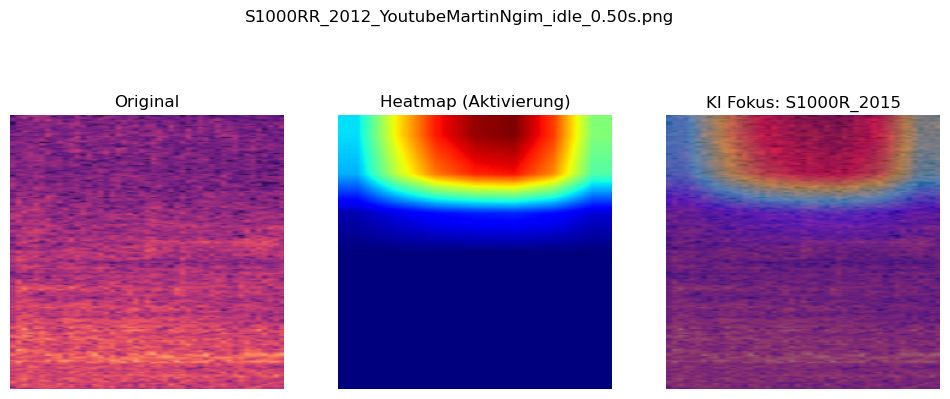

In [40]:
# --- Grad-CAM für die 2012er RR (YouTube) ---

# Wähle ein repräsentatives Segment aus dem YouTube-Ordner
youtube_2012_file = [f for f in youtube_imgs if "0.50s" in f][0] 
test_path_2012 = os.path.join(dataset_path, youtube_2012_file)

print(f"Generiere Grad-CAM für: {youtube_2012_file}")

# Nutze die bestehende Funktion
visualize_gradcam(test_path_2012, model, data_transforms, train_dataset.class_names)